# EDA for Treatment (Z): Timely College Entrance
Binary. 1 if first recorded college entrance between 18 and 20 (inclusive) and 0 otherwise

In [47]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
pd.set_option("display.max_columns", None)

# PUT GITHUB ROOT PATH HERE
root_dir = "/Users/albert/Library/CloudStorage/OneDrive-andrew.cmu.edu/Documents/CMU 26-27/Undergraduate Research/Victimization/Code/capstone_victimization"
dir = root_dir + "/Data and Resources"
os.chdir(dir)
data = pd.read_csv(os.path.join(dir, "final_data.csv"))
print(data.shape)
print(data.columns)

(8984, 28)
Index(['respondent_id', 'timely_college', 'violent_victimization_18_24',
       'earliest_arrest_date', 'total_number_of_incarcerations',
       'r_threatened_to_be_hurt_at_school', 'r_in_a_fight_at_school',
       'days_r_absent_from_school', 'teachers_good',
       'discipline_is_fair_agree_disagree', 'percent_of_peers_who_smoke',
       'percent_of_peers_who_get_drunk_1_times_a_month',
       'percent_of_peers_belong_to_a_gang',
       'percent_of_peers_who_have_had_sex', 'what_year_first_arrest_arrest_10',
       'bullying_victim_before_age_12', 'r_victim_of_bullying_12_18_years',
       'percent_chance_r_victim_of_violent_crime_by_next_year', 'sex',
       'r_ever_live_through_hard_times', 'household_net_worth',
       'household_size', 'biological_father_education',
       'biological_mother_education', 'race_ethnicity',
       'asvab_math_verbal_score_percent', 'mother_serve_prison_sentence',
       'father_serve_prison_sentence'],
      dtype='str')


In [48]:
data['timely_college'].describe()

count    8846.000000
mean        0.470043
std         0.499130
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: timely_college, dtype: float64

In [49]:
data['violent_victimization_18_24'].describe()

count    8472.000000
mean        0.061379
std         0.240038
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: violent_victimization_18_24, dtype: float64

In [50]:
data['violent_victimization_18_24'].value_counts(dropna=False)

violent_victimization_18_24
0.0    7952
1.0     520
NaN     512
Name: count, dtype: int64

In [51]:
data['timely_college'].value_counts(dropna=False)

timely_college
0.0    4688
1.0    4158
NaN     138
Name: count, dtype: int64

In [52]:
data[data['timely_college'].isna()]['violent_victimization_18_24'].value_counts(dropna=False)

violent_victimization_18_24
NaN    133
0.0      5
Name: count, dtype: int64

In [53]:
full_data = pd.read_csv(os.path.join(dir, "full_data.csv"))

/var/folders/sw/wmlbswl578s997jghc7ckfyw0000gn/T/ipykernel_67997/3825839610.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  full_data["timely_category_4"] = np.select(


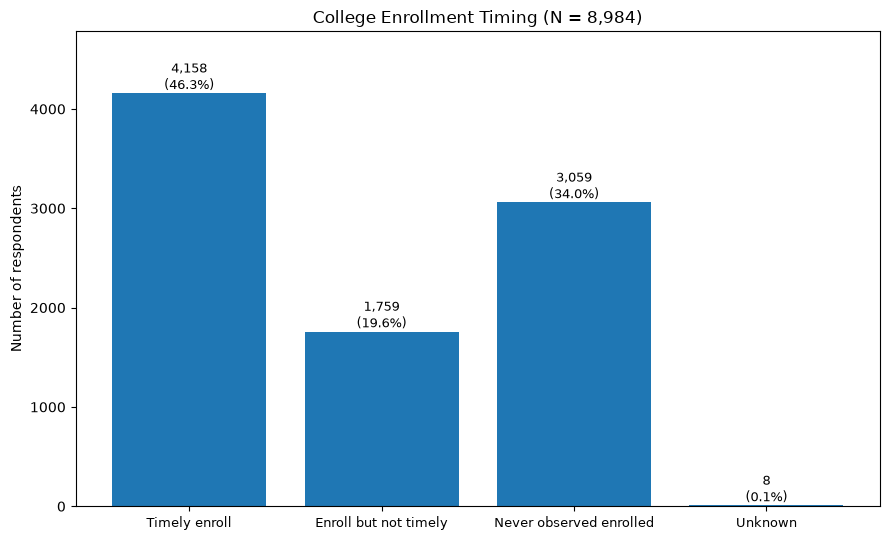

timely_category_4
Timely enroll              4158
Enroll but not timely      1759
Never observed enrolled    3059
Unknown                       8

Note: 'Unknown' here includes both true Unknown college_history AND 'Grad program only' respondents (7 of them), since neither has a resolvable timely/not-timely status.


In [54]:
# ============================================================
# PLOT: ENROLLMENT TIMING CATEGORY (4 groups)
# ============================================================

TIMELY_ORDER = [
    "Timely enroll",
    "Enroll but not timely",
    "Never observed enrolled",
    "Unknown",
]

# "Grad program only" has no resolvable timely/not-timely status (same as
# Unknown - treatment is NaN either way), so it's folded into "Unknown" here
# to match the requested 4-category breakdown.
full_data["timely_category_4"] = np.select(
    [
        full_data["timely_college"].eq(1),
        full_data["college_history"].eq("Enrolled") & full_data["timely_college"].eq(0),
        full_data["college_history"].eq("Never observed enrolled"),
    ],
    [
        "Timely enroll",
        "Enroll but not timely",
        "Never observed enrolled",
    ],
    default="Unknown",   # catches true "Unknown" AND "Grad program only"
)

summary = full_data["timely_category_4"].value_counts().reindex(TIMELY_ORDER, fill_value=0)
total = summary.sum()

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.bar(range(len(summary)), summary.values)
for i, v in enumerate(summary.values):
    ax.text(i, v, f"{int(v):,}\n({v / total * 100:.1f}%)",
            ha="center", va="bottom", fontsize=9)

ax.set_xticks(range(len(summary)))
ax.set_xticklabels(summary.index, fontsize=9)
ax.set_ylabel("Number of respondents")
ax.set_title(f"College Enrollment Timing (N = {total:,})")
ax.margins(y=0.15)
plt.tight_layout()
plt.show()

print(summary.to_string())
print(f"\nNote: 'Unknown' here includes both true Unknown college_history AND "
      f"'Grad program only' respondents "
      f"({(full_data['college_history'] == 'Grad program only').sum():,} of them), "
      f"since neither has a resolvable timely/not-timely status.")

treatment defined           : 8,846
outcome defined             : 8,472
both defined (plotted below): 8,467

                               n  n_victimized  rate_pct
Timely enrollment\n(Z = 1)  3987         233.0      5.84
Not timely\n(Z = 0)         4480         287.0      6.41


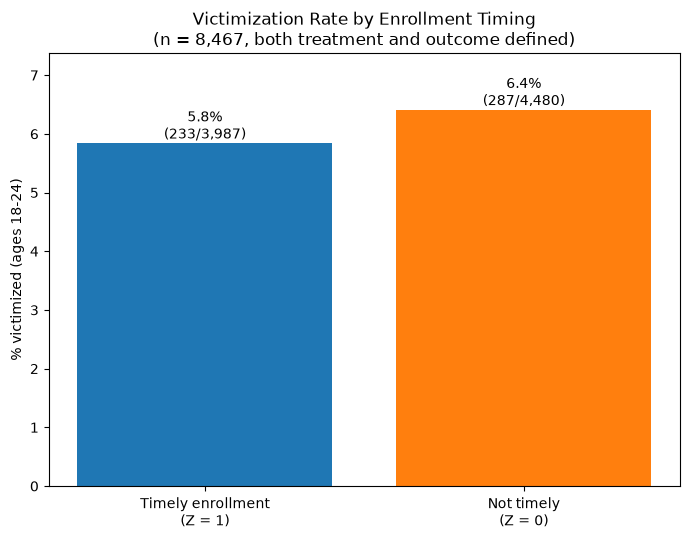

In [55]:
# ============================================================
# PLOT: VICTIMIZATION RATE, TIMELY vs NOT-TIMELY ENROLLMENT
# ============================================================

both_defined = data["timely_college"].notna() & data["violent_victimization_18_24"].notna()
print(f"treatment defined           : {data['timely_college'].notna().sum():,}")
print(f"outcome defined             : {data['violent_victimization_18_24'].notna().sum():,}")
print(f"both defined (plotted below): {both_defined.sum():,}")

summary = (
    data.loc[both_defined]
    .groupby("timely_college")["violent_victimization_18_24"]
    .agg(n="count", n_victimized="sum")
    .reindex([1.0, 0.0])   # timely first, not-timely second
)
summary["rate_pct"] = (summary["n_victimized"] / summary["n"] * 100).round(2)
summary.index = ["Timely enrollment\n(Z = 1)", "Not timely\n(Z = 0)"]

print()
print(summary.to_string())

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.bar(range(len(summary)), summary["rate_pct"], color=["tab:blue", "tab:orange"])
for i, (rate, n, nv) in enumerate(zip(summary["rate_pct"], summary["n"], summary["n_victimized"])):
    ax.text(i, rate, f"{rate:.1f}%\n({int(nv):,}/{int(n):,})",
            ha="center", va="bottom", fontsize=10)

ax.set_xticks(range(len(summary)))
ax.set_xticklabels(summary.index, fontsize=10)
ax.set_ylabel("% victimized (ages 18-24)")
ax.set_title(f"Victimization Rate by Enrollment Timing\n(n = {both_defined.sum():,}, both treatment and outcome defined)")
ax.margins(y=0.15)
plt.tight_layout()
plt.show()